# Visualization notebook 
## purpose : 
    - Visualize the data stored on the *swapi.db* database
    - Generate charts using seaborn and matplotlib to be mentioned on the final_report
    - Save charts on this folder ../Output/charts/
    - Conclude insights 
## Data :
    - Data used in this notebook is found on the swapi.db database, 
    
    * Note : Some tables used in this notebook are generated on the analysis.ipynb notebook 
## Results :
    - By running this notebook, Charts will be generated in this folder :  ../Output/chartsb/

In [4]:
# Importing tools needed
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# connect to the Database (swapi.db)
conn = sqlite3.connect("../Database/swapi.db")

In [6]:
# Creating a function to load the new analysis tables created on the analysis notebook
def csv_connect(table) :
    return pd.read_csv(f"../Output/tables/{table}.csv")

### Loading the tables (csv/sql)

In [55]:
people = pd.read_sql(f"select * from people", conn)
# Csv analysis tables
tallest_ppl = csv_connect("tallest_ppl")
heaviest_ppl = csv_connect("heaviest_ppl")
oldest_ppl = csv_connect("oldest_ppl")
planets_population = csv_connect("planets_population")
tallest_sp  = csv_connect("tallest_sp")
planets_water = csv_connect("planets_water")

### Gender status (people table)

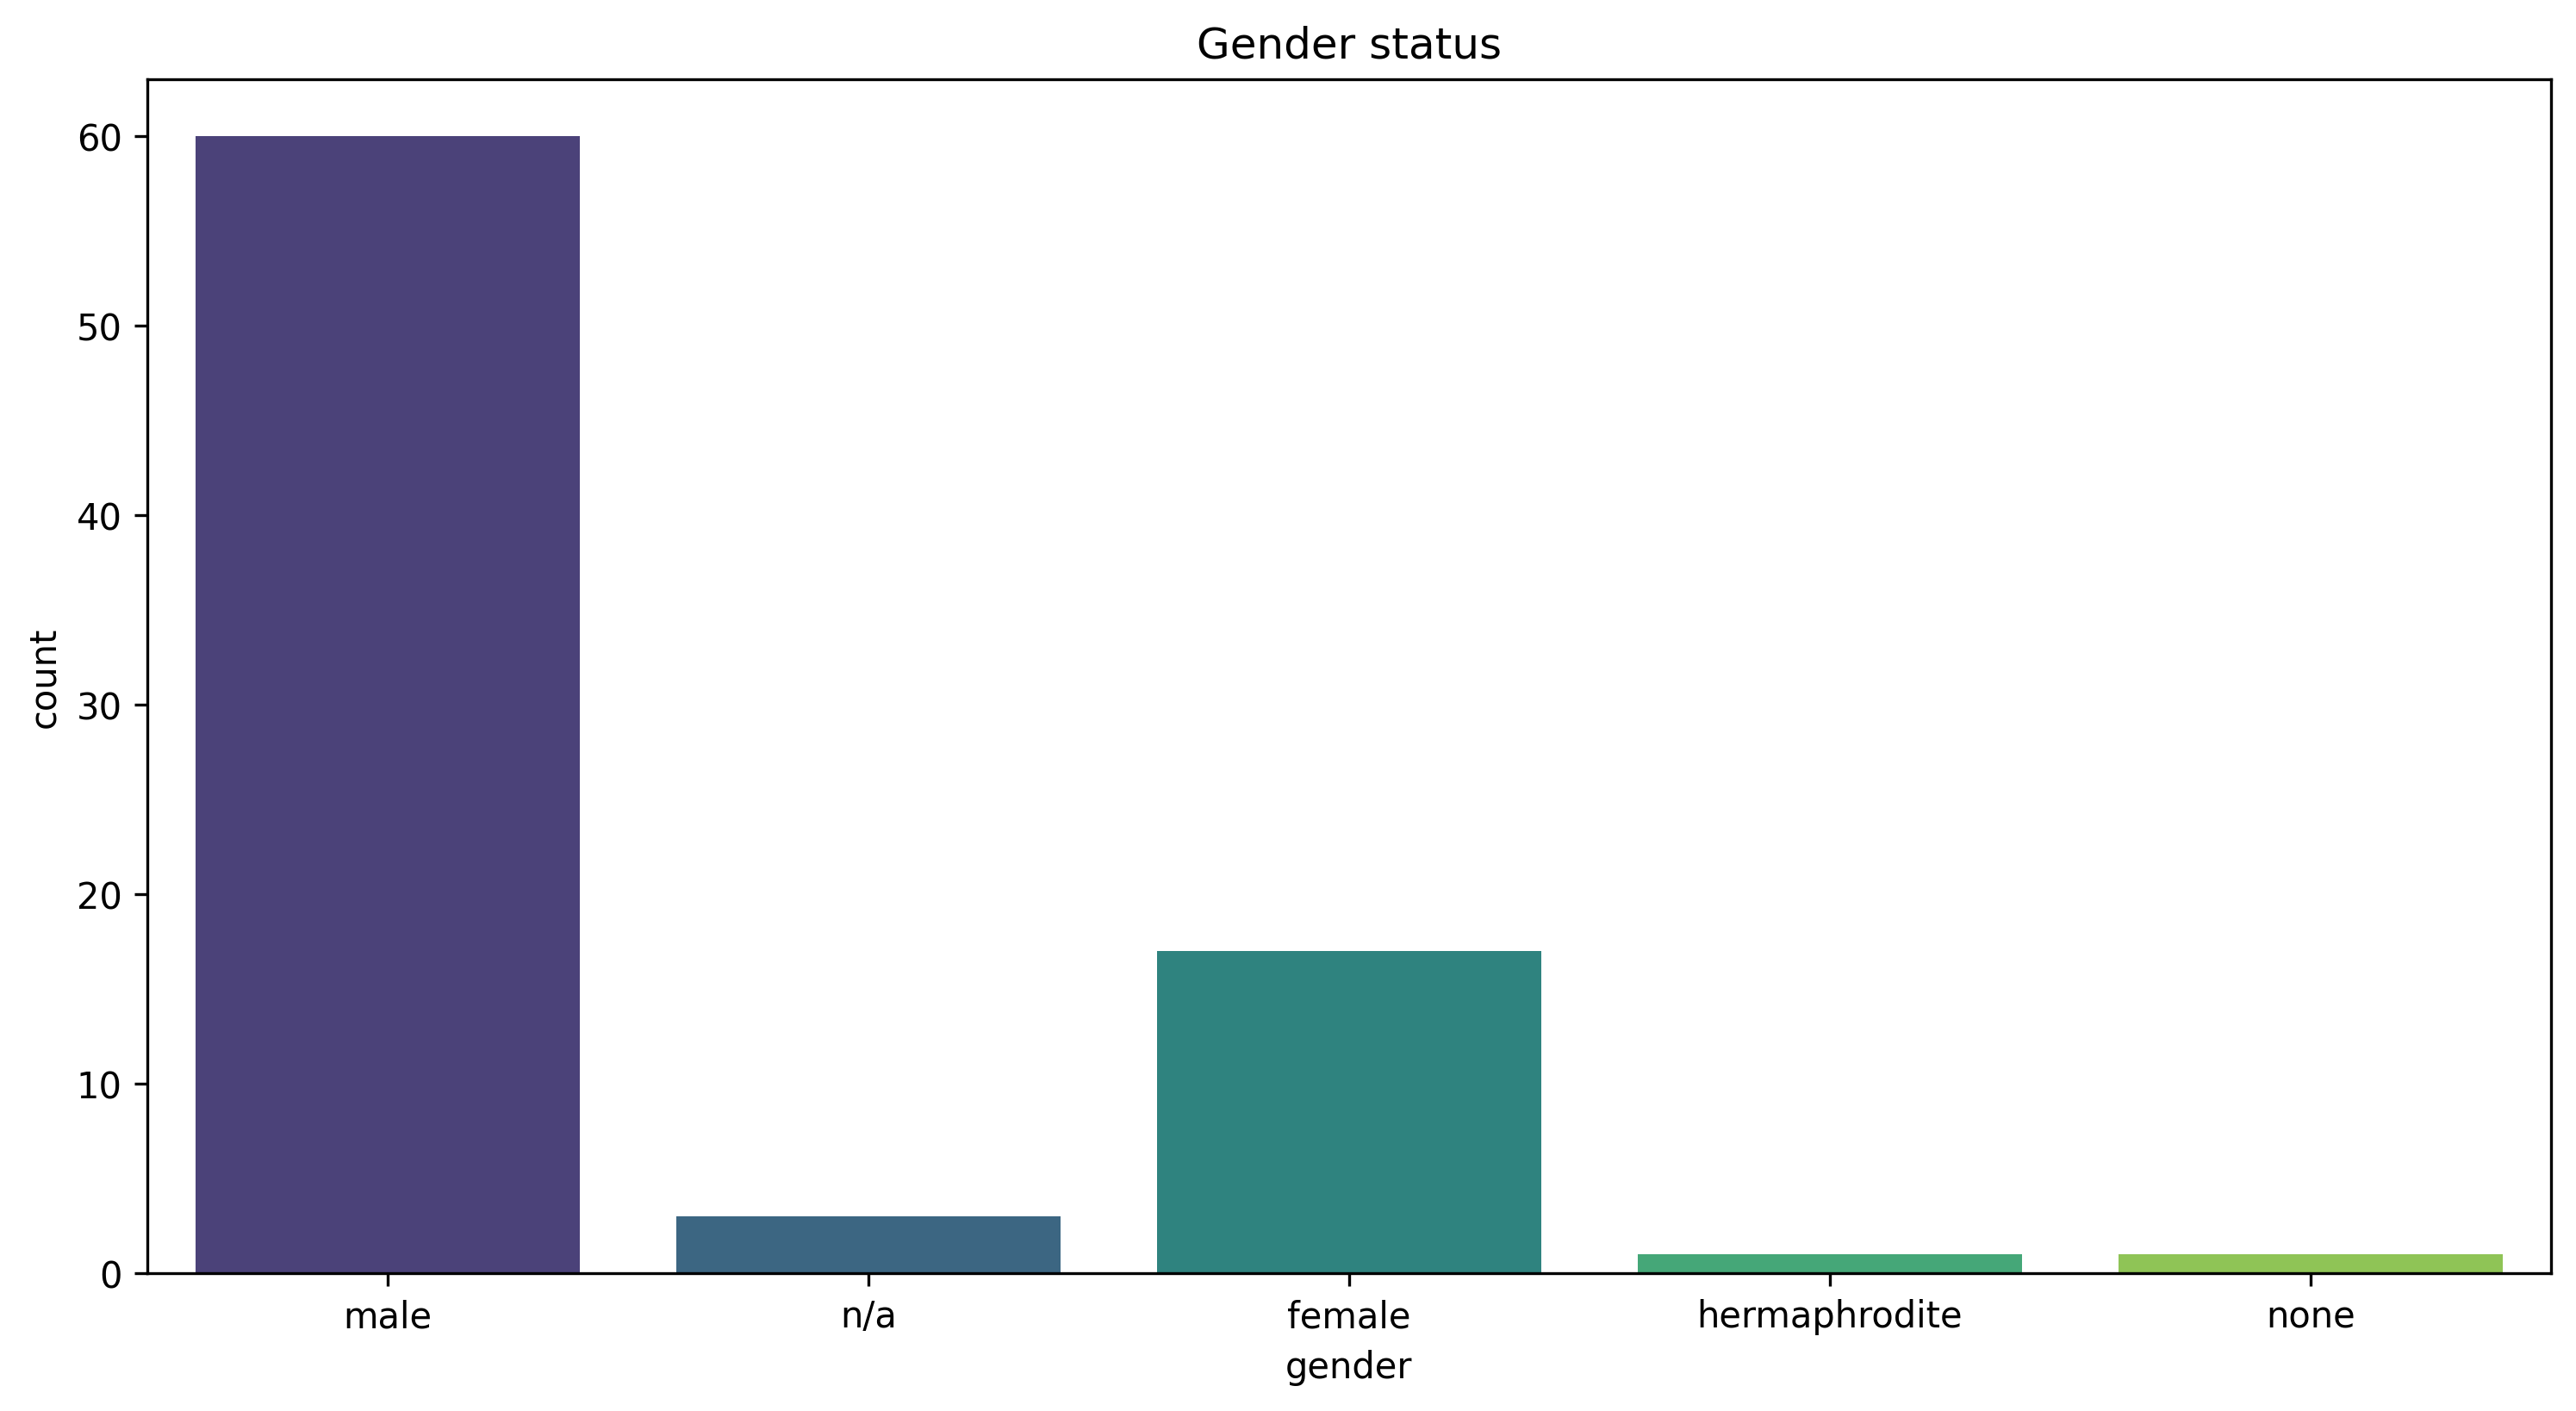

In [25]:
fig, ax = plt.subplots(figsize = (12, 6), dpi = 300)
sns.countplot(data=people,x="gender",hue="gender",palette="viridis")
plt.title("Gender status")
plt.savefig("../Output/charts/gender_status.png", dpi=300)

> As we can see in the output chart, The most popular gender is "**male**"

### Average height per gender (people table)

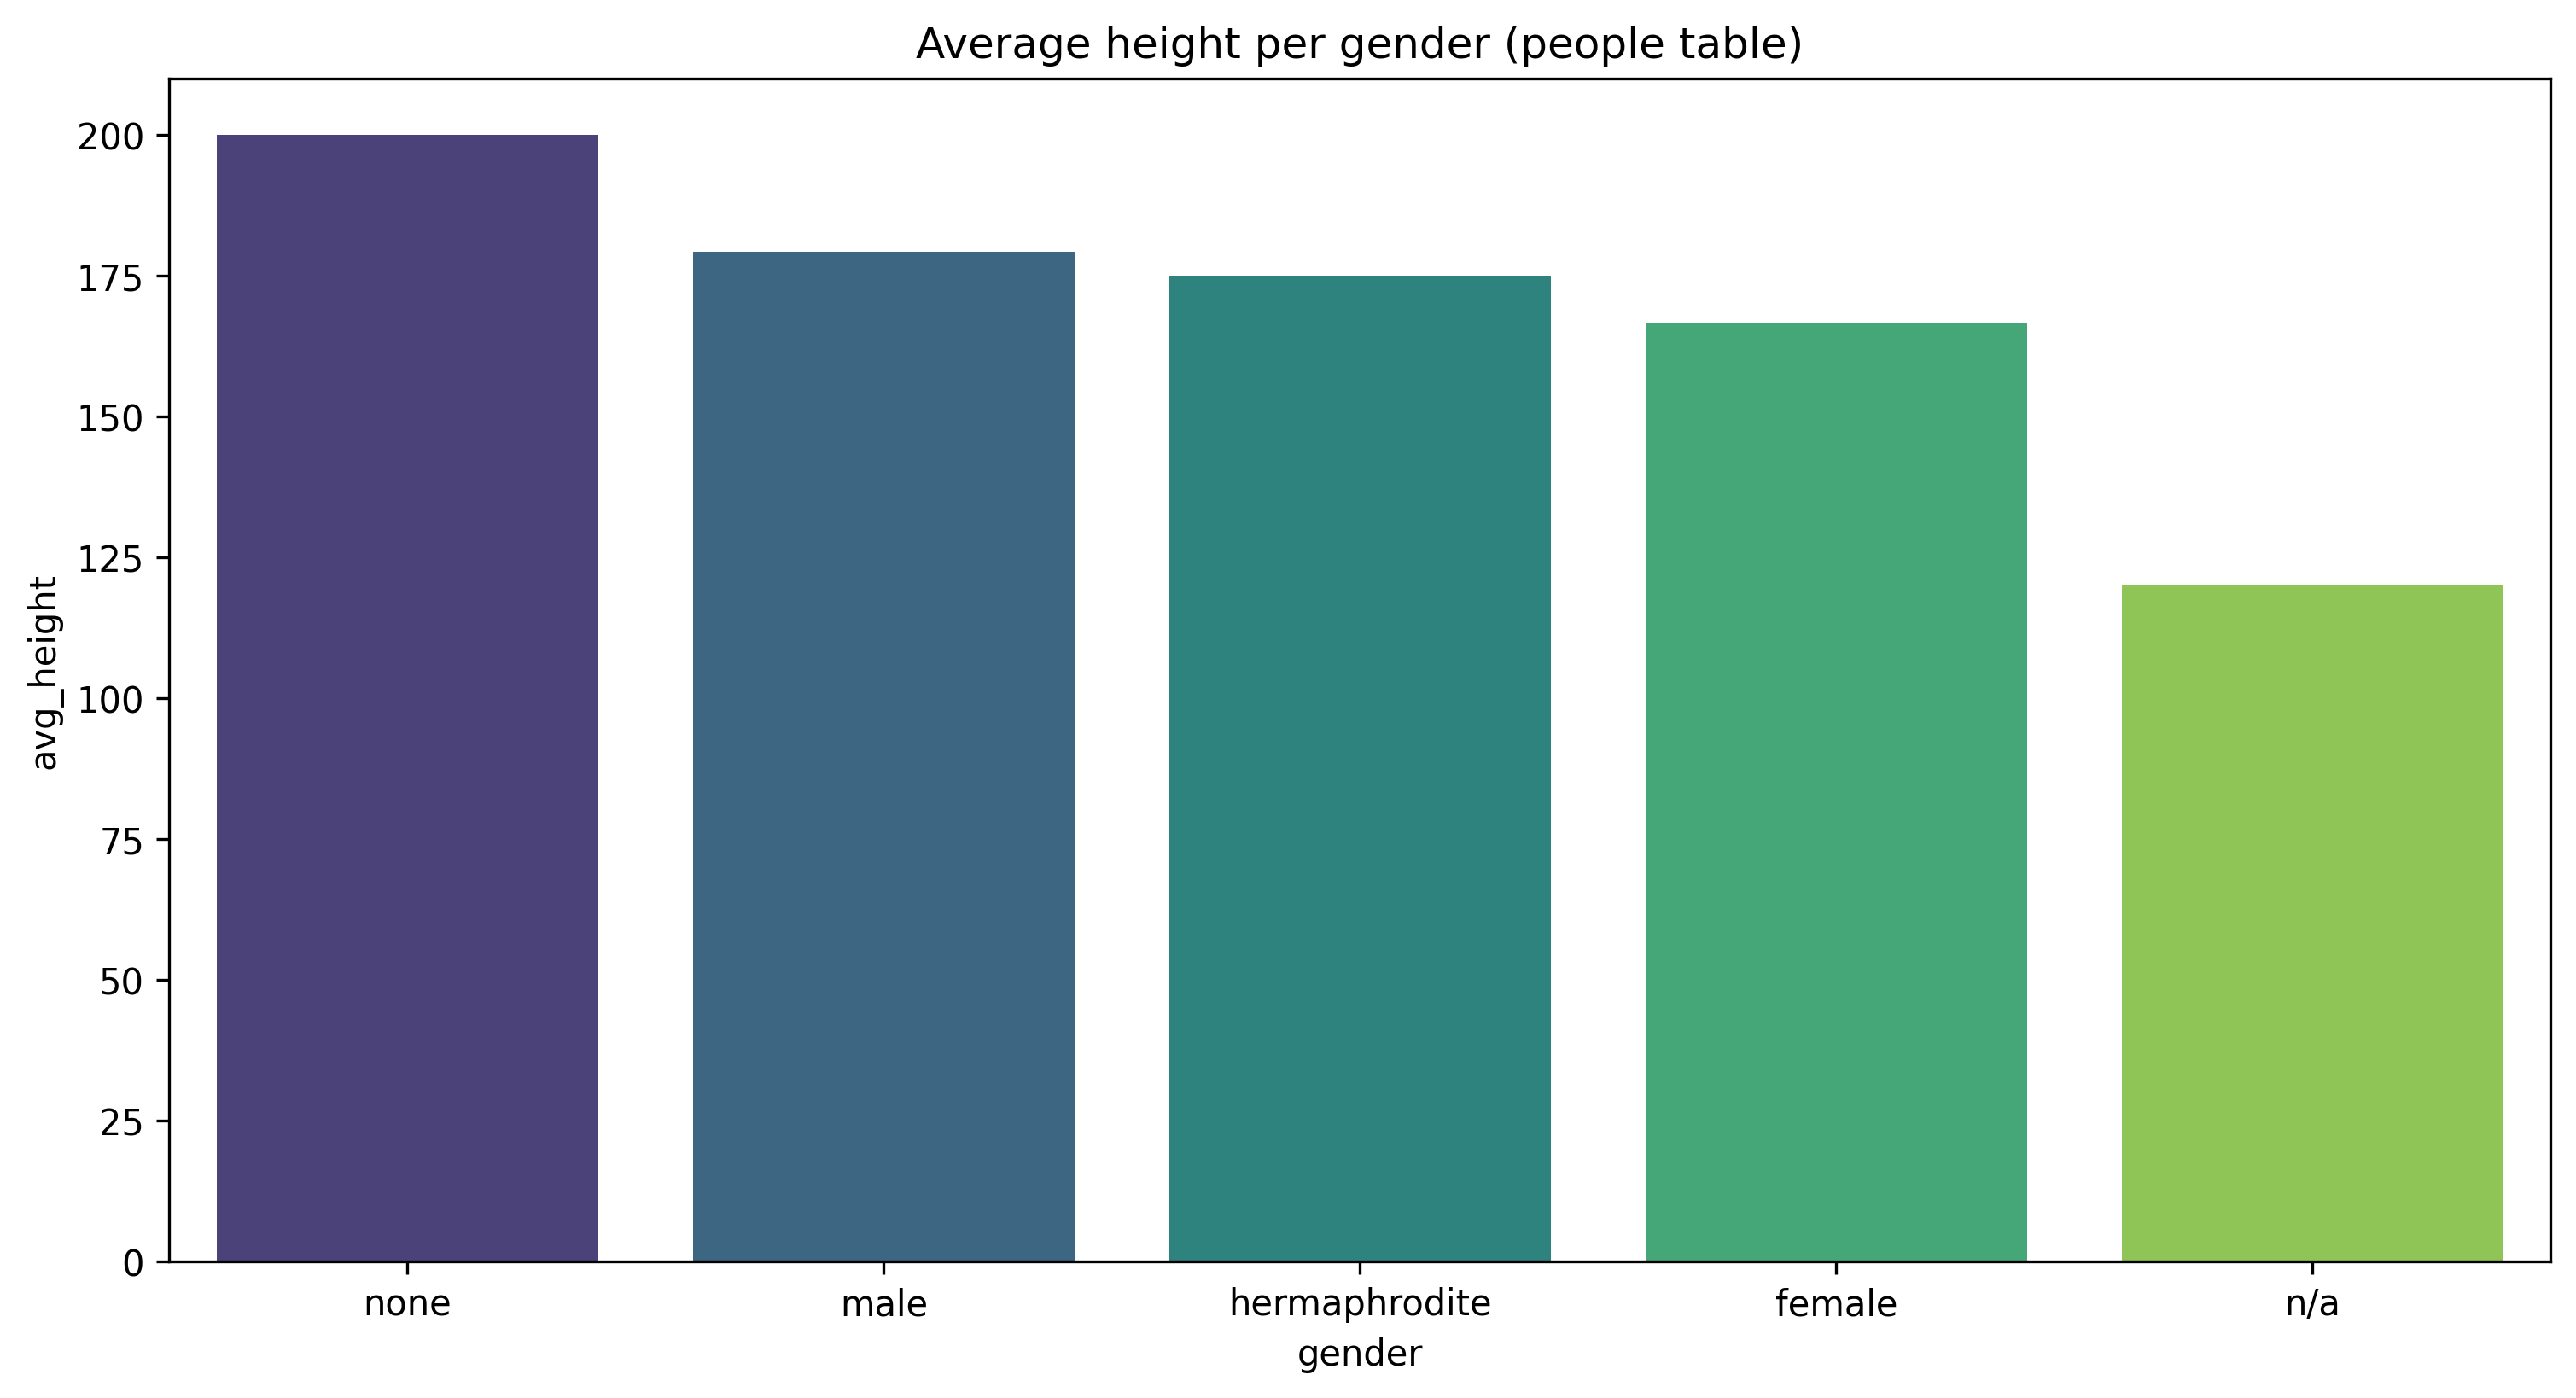

In [26]:
people["height"] = pd.to_numeric(people["height"], errors="coerce")
gender_average_height = (people
    .groupby("gender")["height"]
    .mean()
    .reset_index(name="avg_height")
    .sort_values(by="avg_height",ascending=False)
                        ).copy()
fig, ax = plt.subplots(figsize = (12, 6), dpi = 300)
sns.barplot(data=gender_average_height,x="gender",y="avg_height",hue="gender",palette="viridis")
plt.title("Average height per gender (people table)")
plt.savefig("../Output/charts/gender_avg_height.png", dpi=300)

> As we can see in the output chart, The tallest gender type by average height is **"none"**

### Tallest people 

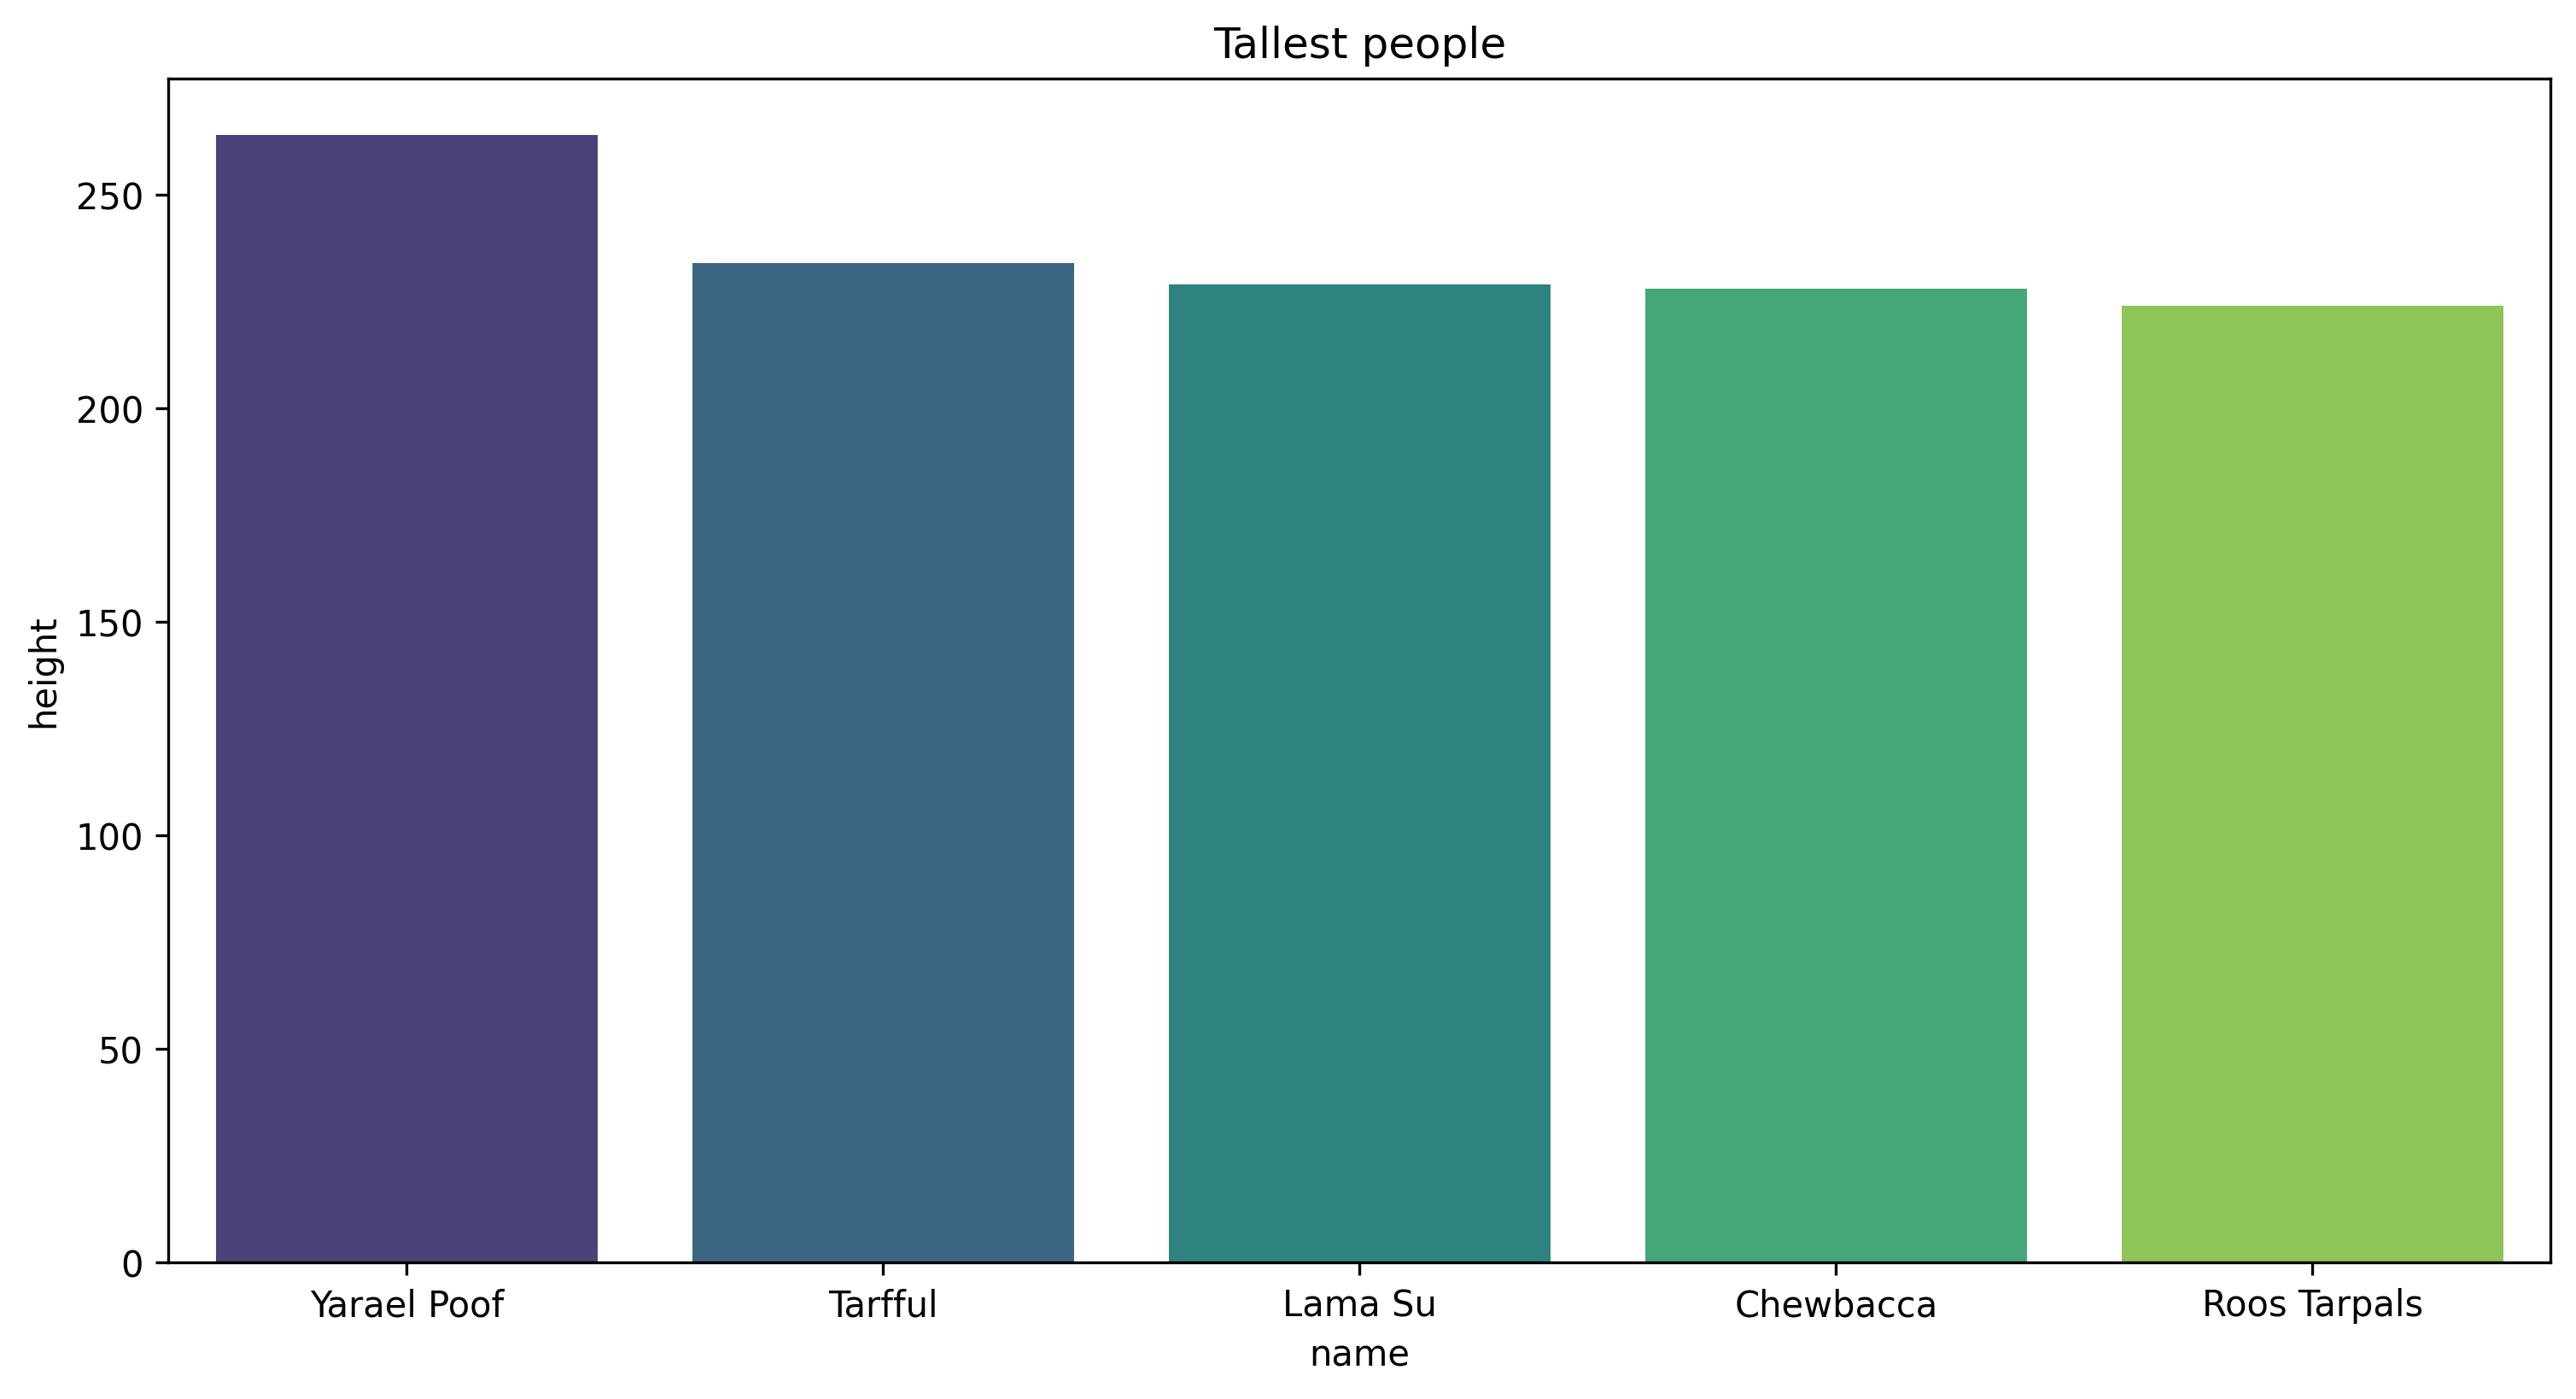

In [30]:
fig, ax = plt.subplots(figsize = (12, 6), dpi = 300)
sns.barplot(data=tallest_ppl.head(5),x="name",y="height",hue="name",palette="viridis")
plt.title("Tallest people")
plt.savefig("../Output/charts/tallest_ppl.png", dpi=300)

>  As we can see in the output chart, The tallest person is ***Yarael poof*** with a height of *250+*

### Heaviest people

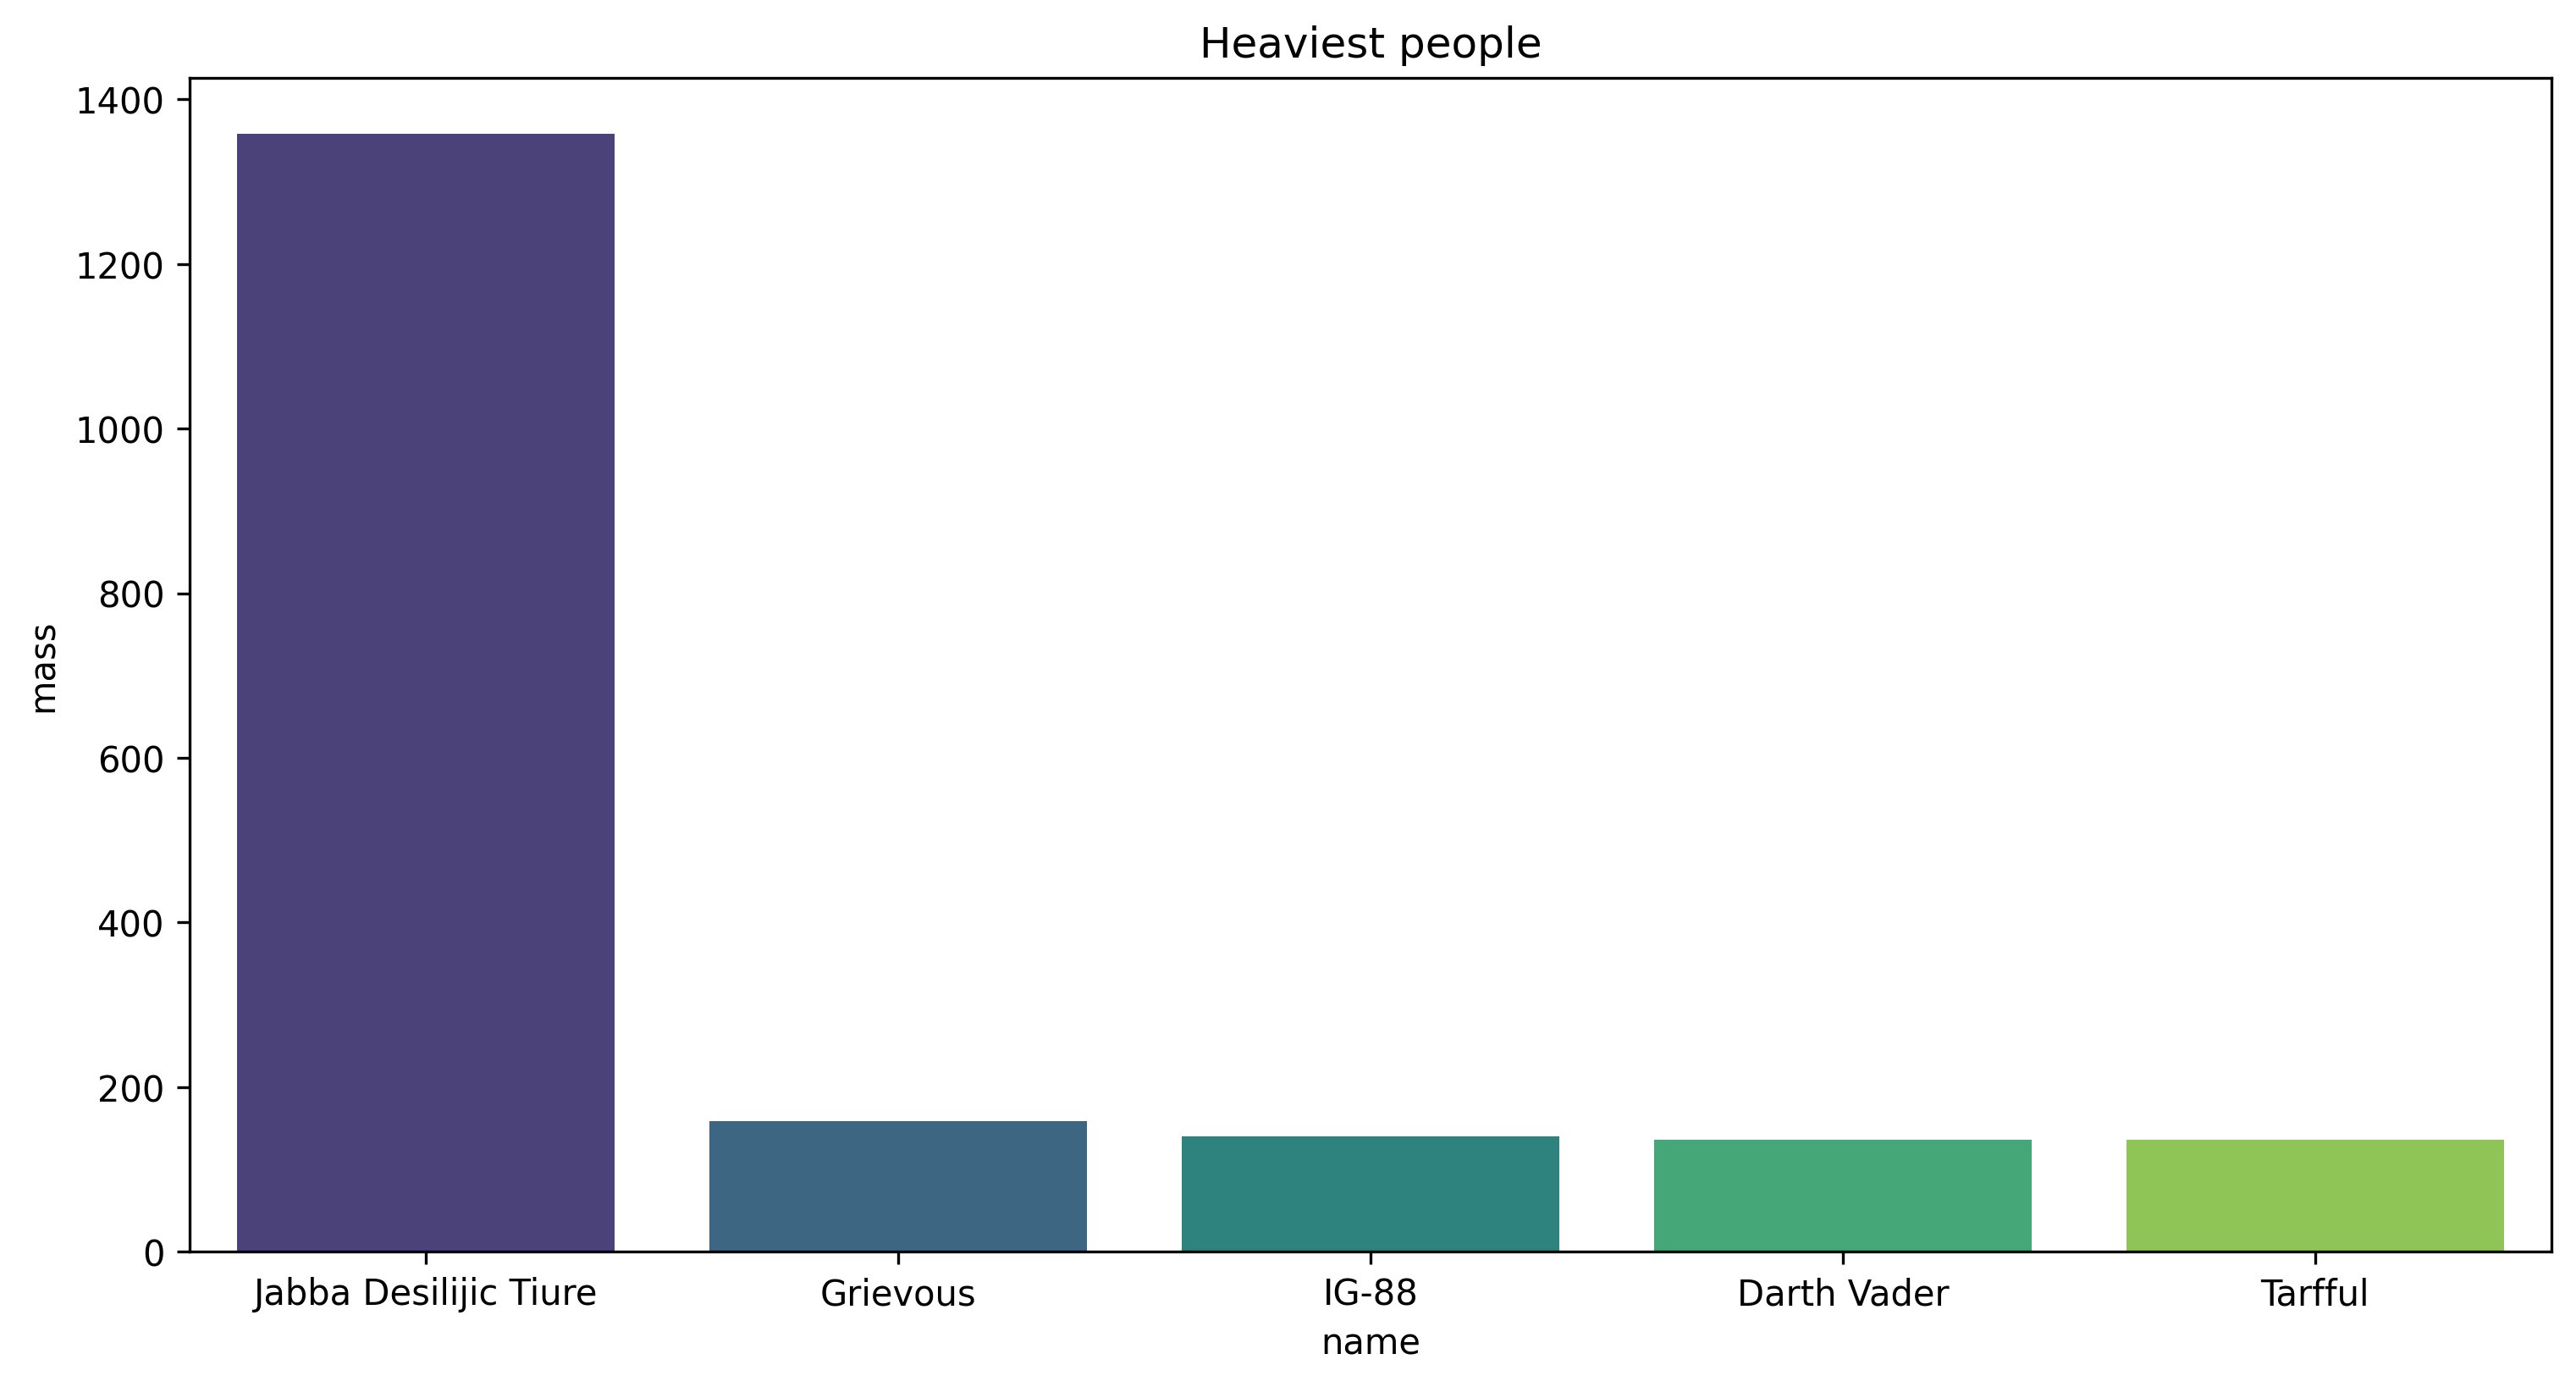

In [49]:
fig, ax = plt.subplots(figsize = (12, 6), dpi = 300)
sns.barplot(data=heaviest_ppl.head(5),x="name",y="mass",hue="name",palette="viridis")
plt.title("Heaviest people")
plt.savefig("../Output/charts/heaviest_ppl.png", dpi=300)

> As we can see on the output chart, The person with the heaviest mass is **Jabba Desilijic Tiure** with a mass of over 1200+

### Oldest people

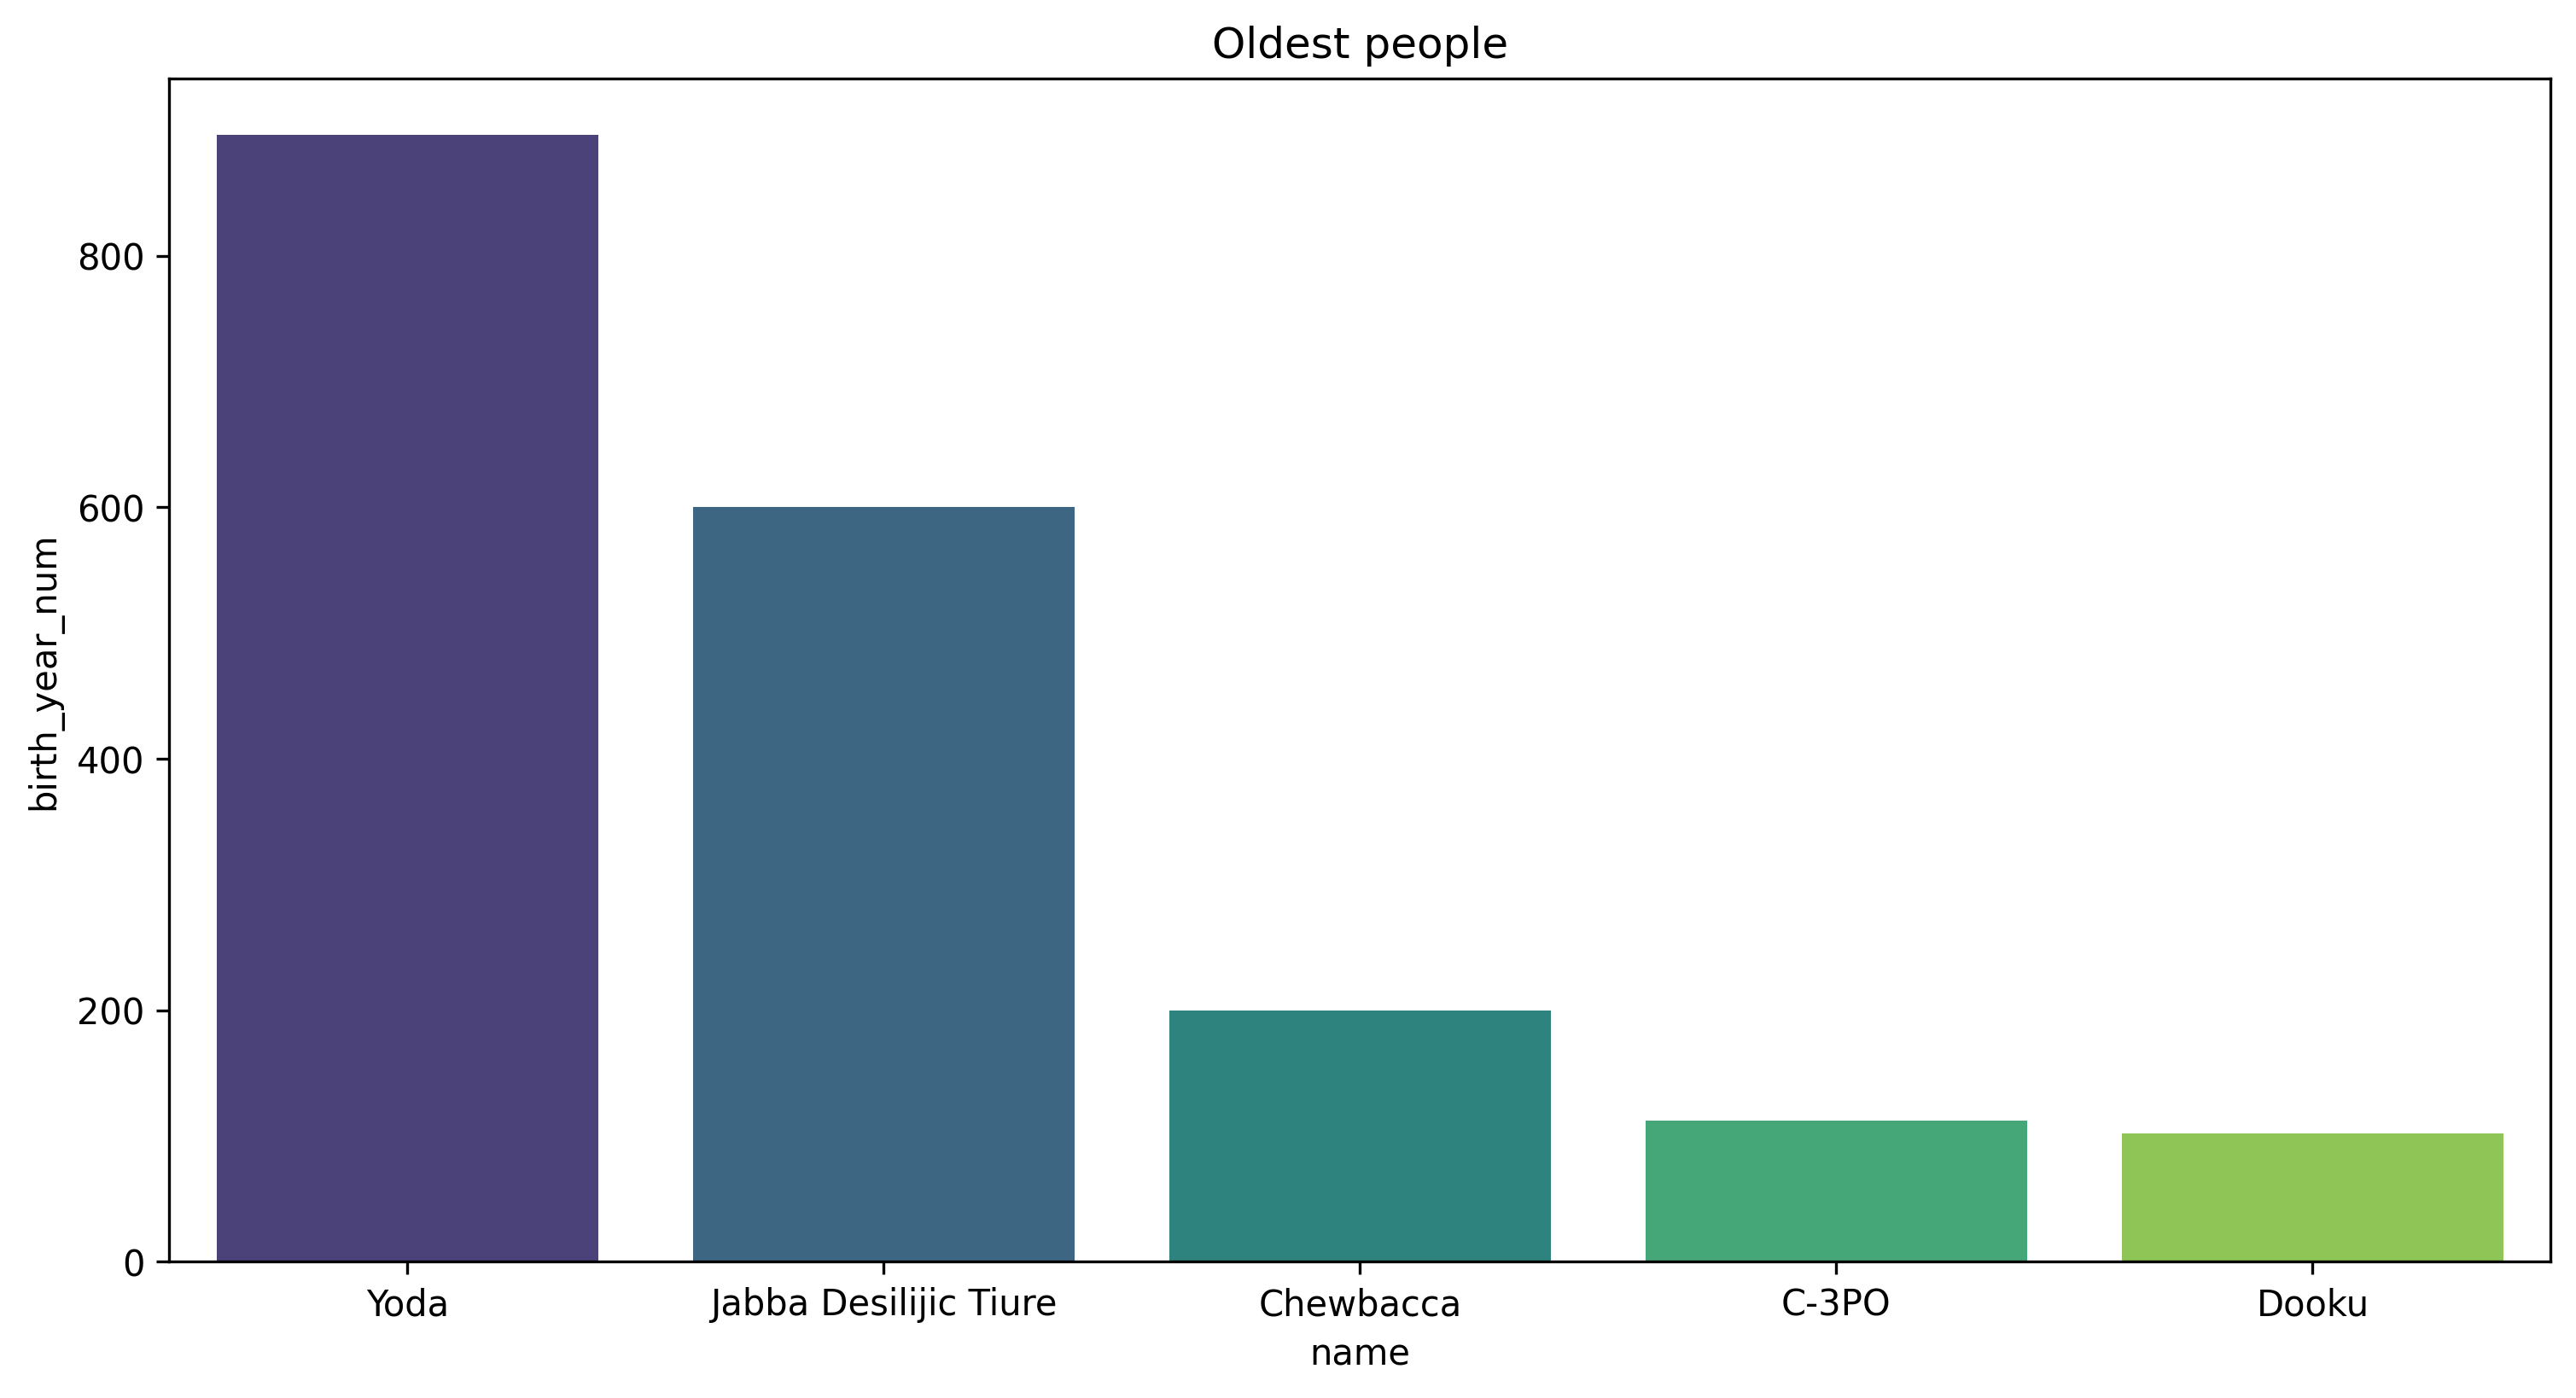

In [53]:
fig, ax = plt.subplots(figsize = (12, 6), dpi = 300)
sns.barplot(data=oldest_ppl.head(5),x="name",y="birth_year_num",hue="name",palette="viridis")
plt.title("Oldest people")
plt.savefig("../Output/charts/oldest_ppl.png", dpi=300)

>  As we can see on the output chart, The oldest person is **Yoda** with an age of 800BBY+ 

### Top planets by population 

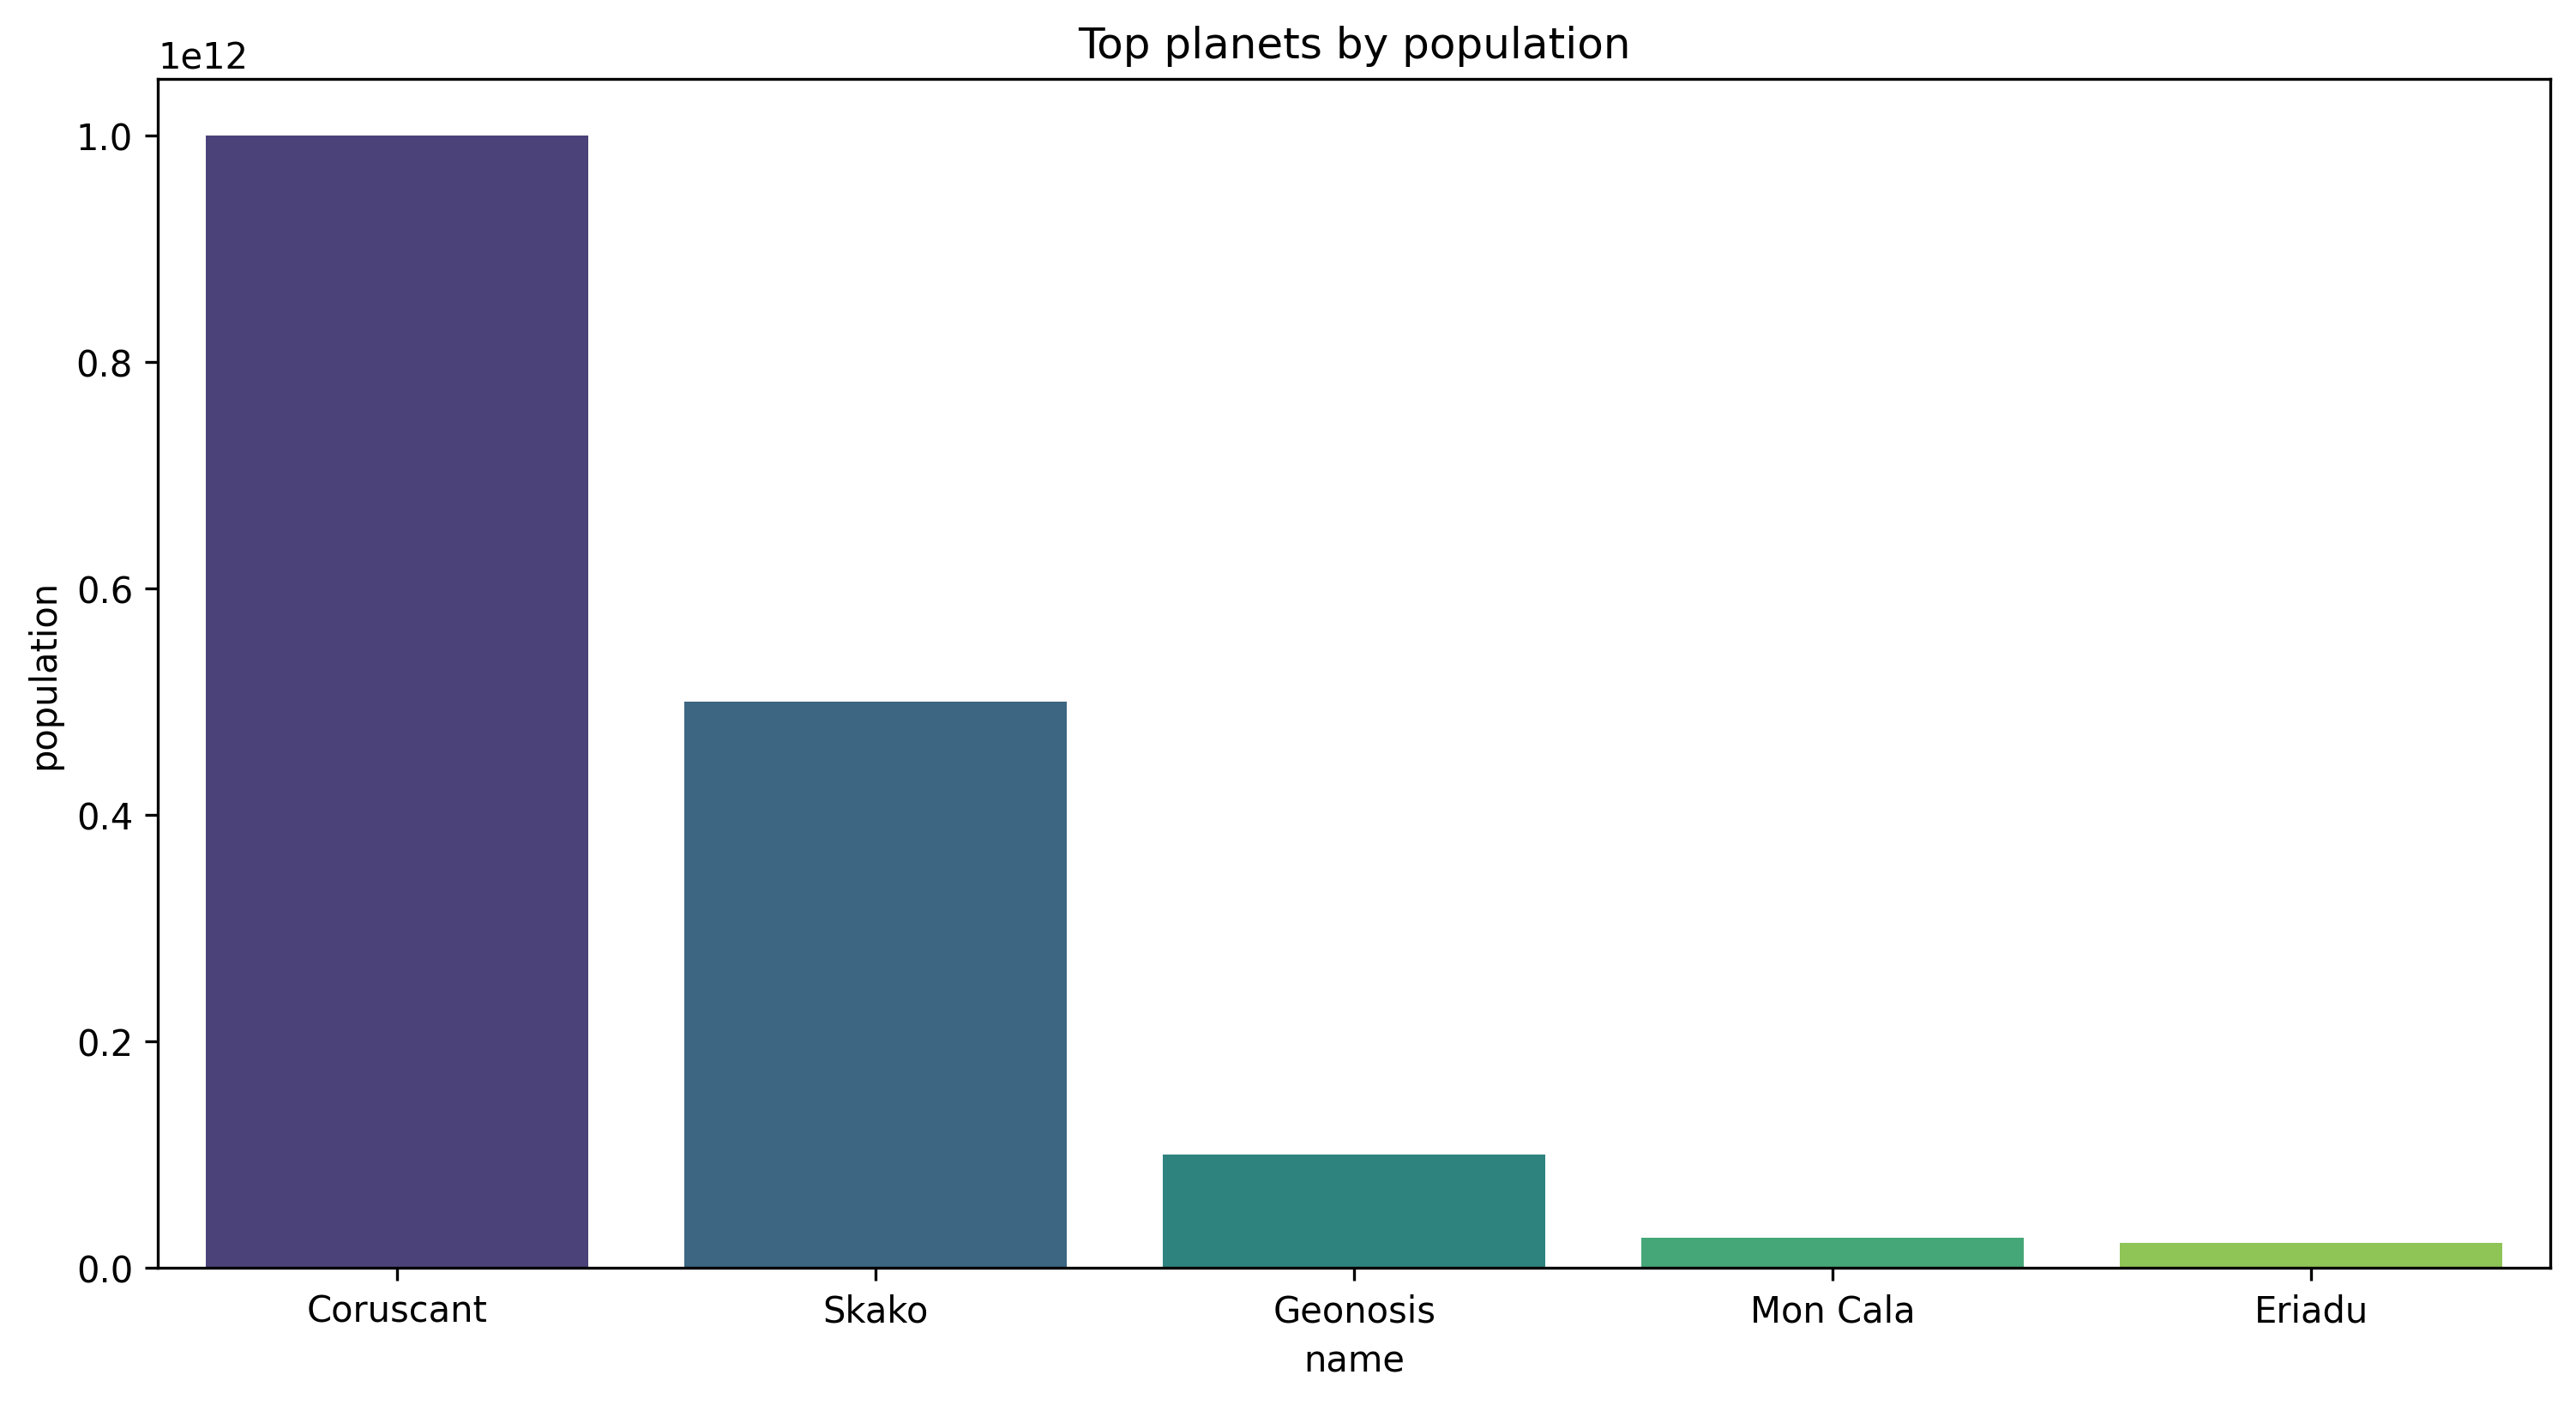

In [58]:
fig, ax = plt.subplots(figsize = (12, 6), dpi = 300)
sns.barplot(data=planets_population.head(5),x="name",y="population",hue="name",palette="viridis")
plt.title("Top planets by population")
plt.savefig("../Output/charts/planets_population.png", dpi=300)

> As we can see from the output chart, The planet with the highest population is **Coruscant** with a population of *1000000000000* residents 

### Tallest species 

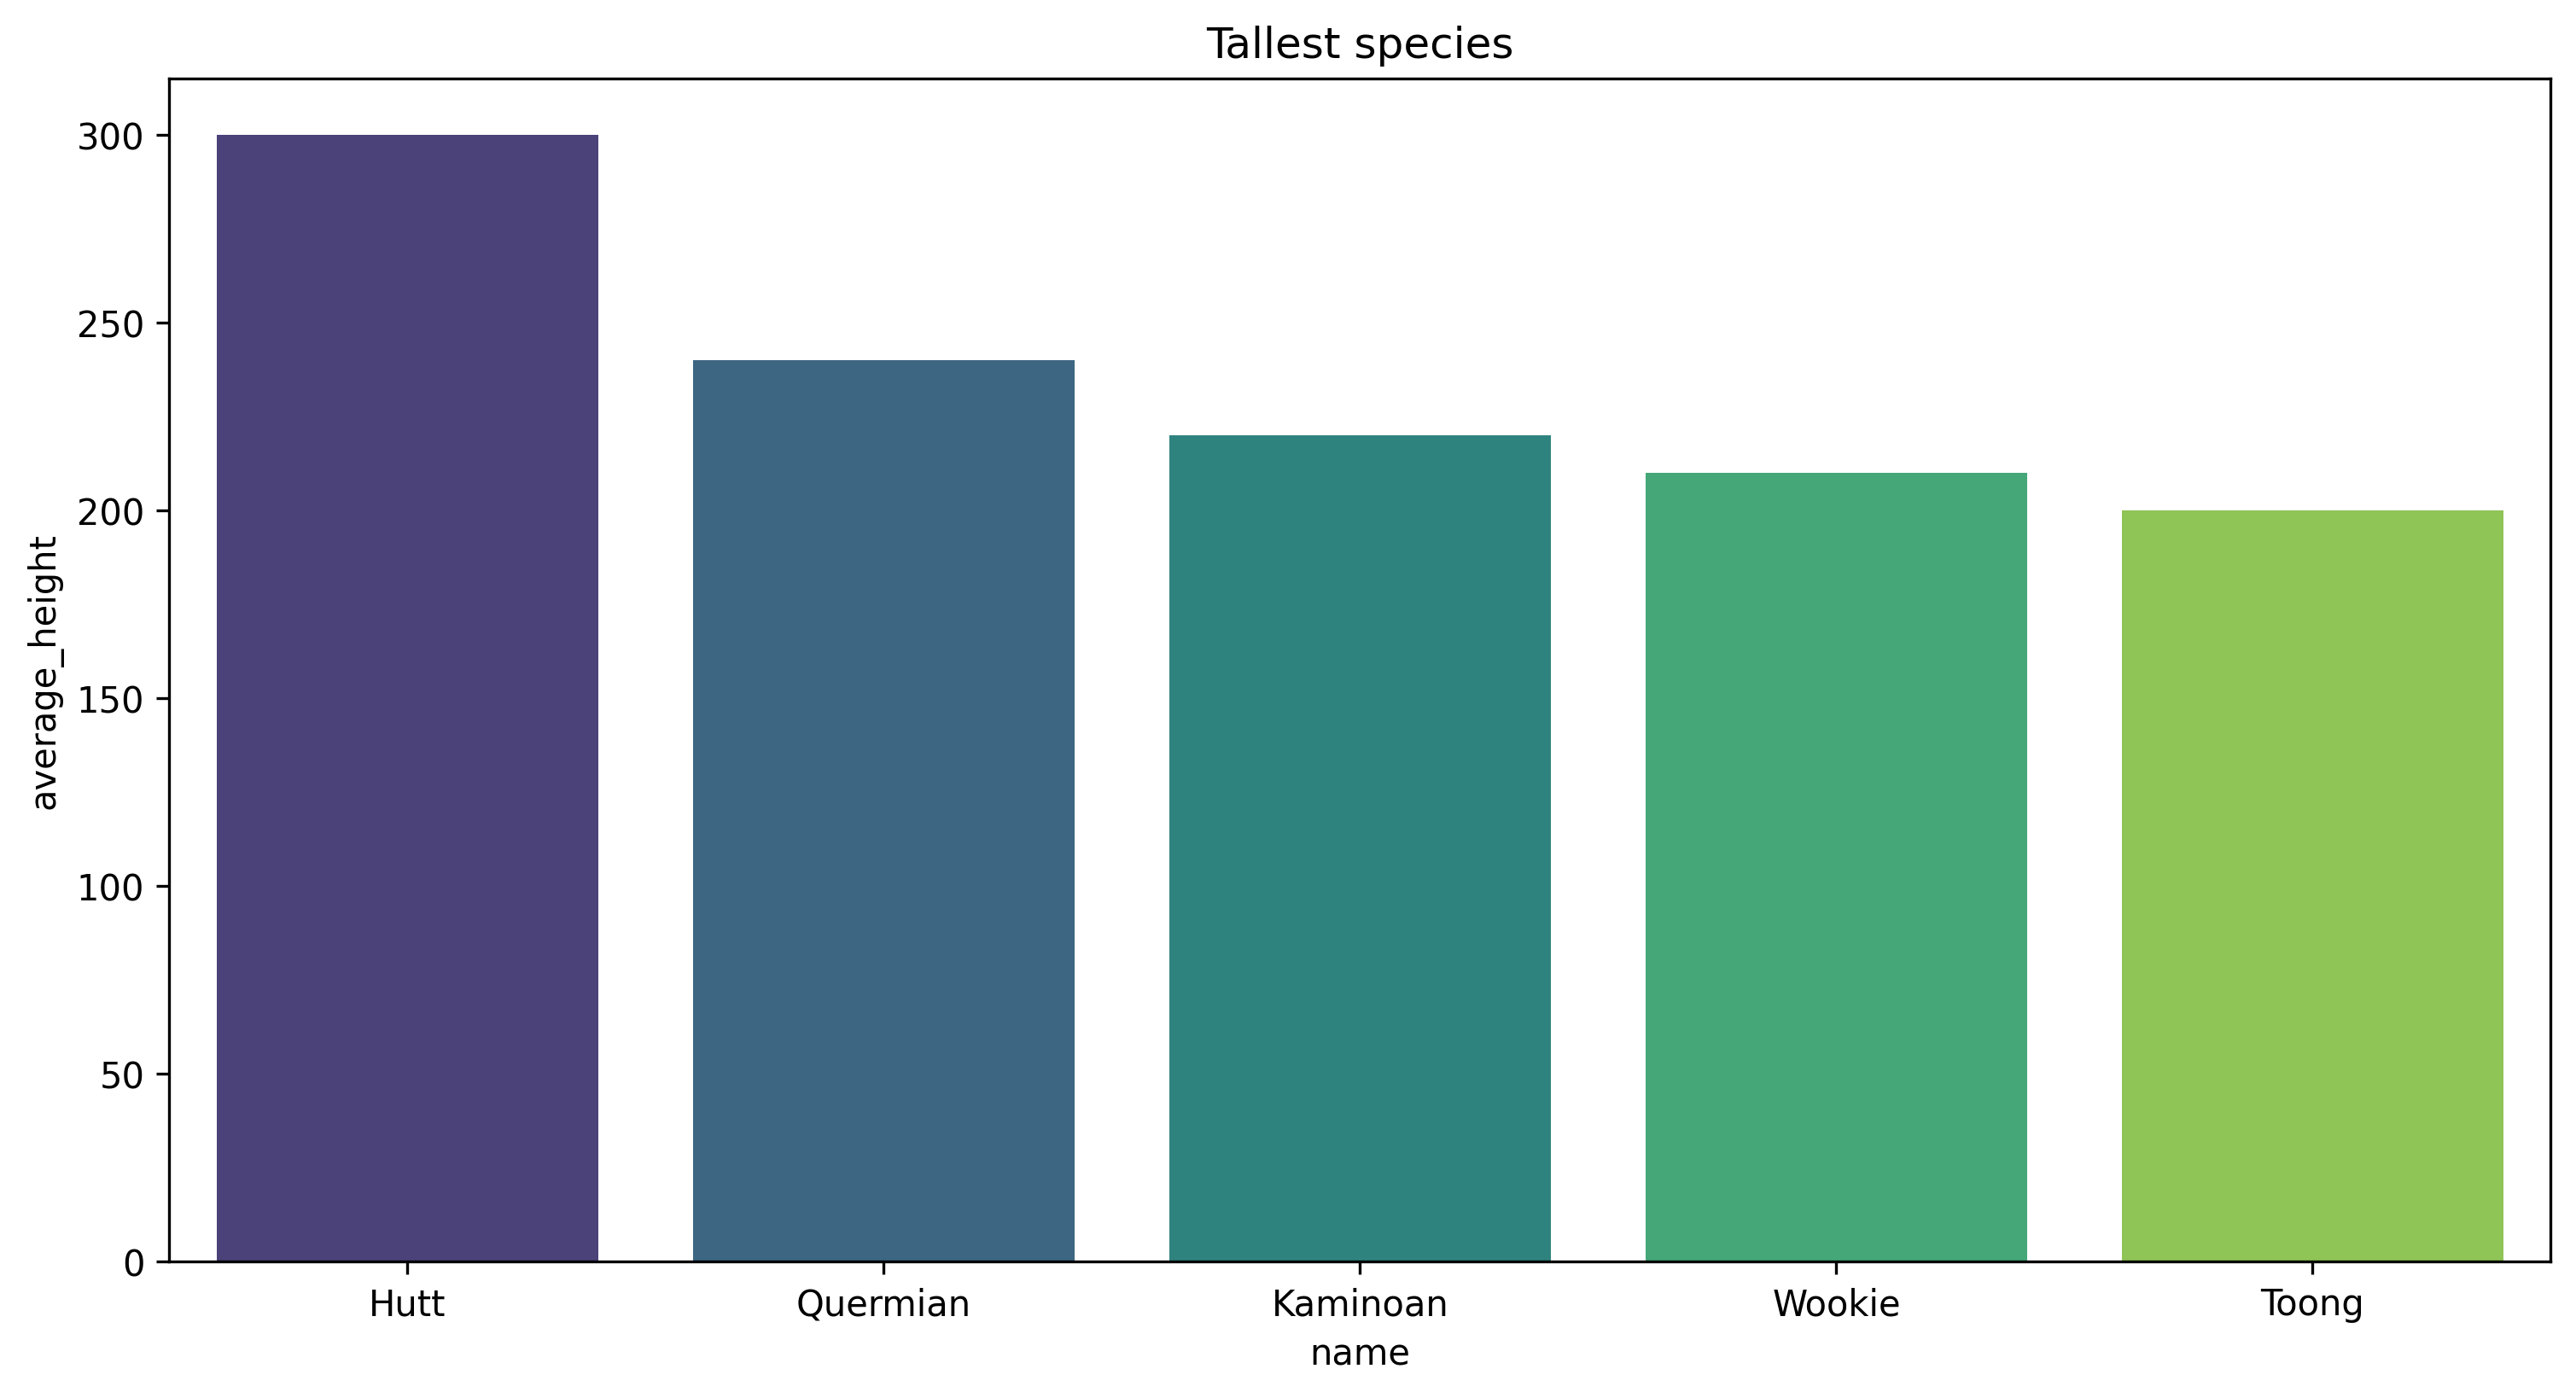

In [61]:
fig, ax = plt.subplots(figsize = (12, 6), dpi = 300)
sns.barplot(data=tallest_sp.head(5),x="name",y="average_height",hue="name",palette="viridis")
plt.title("Tallest species")
plt.savefig("../Output/charts/tallest_sp.png", dpi=300)

> As we can see in the output chart, The tallest species is the **Hutt** with an average height of 300 

### Planets with the highest water surface  

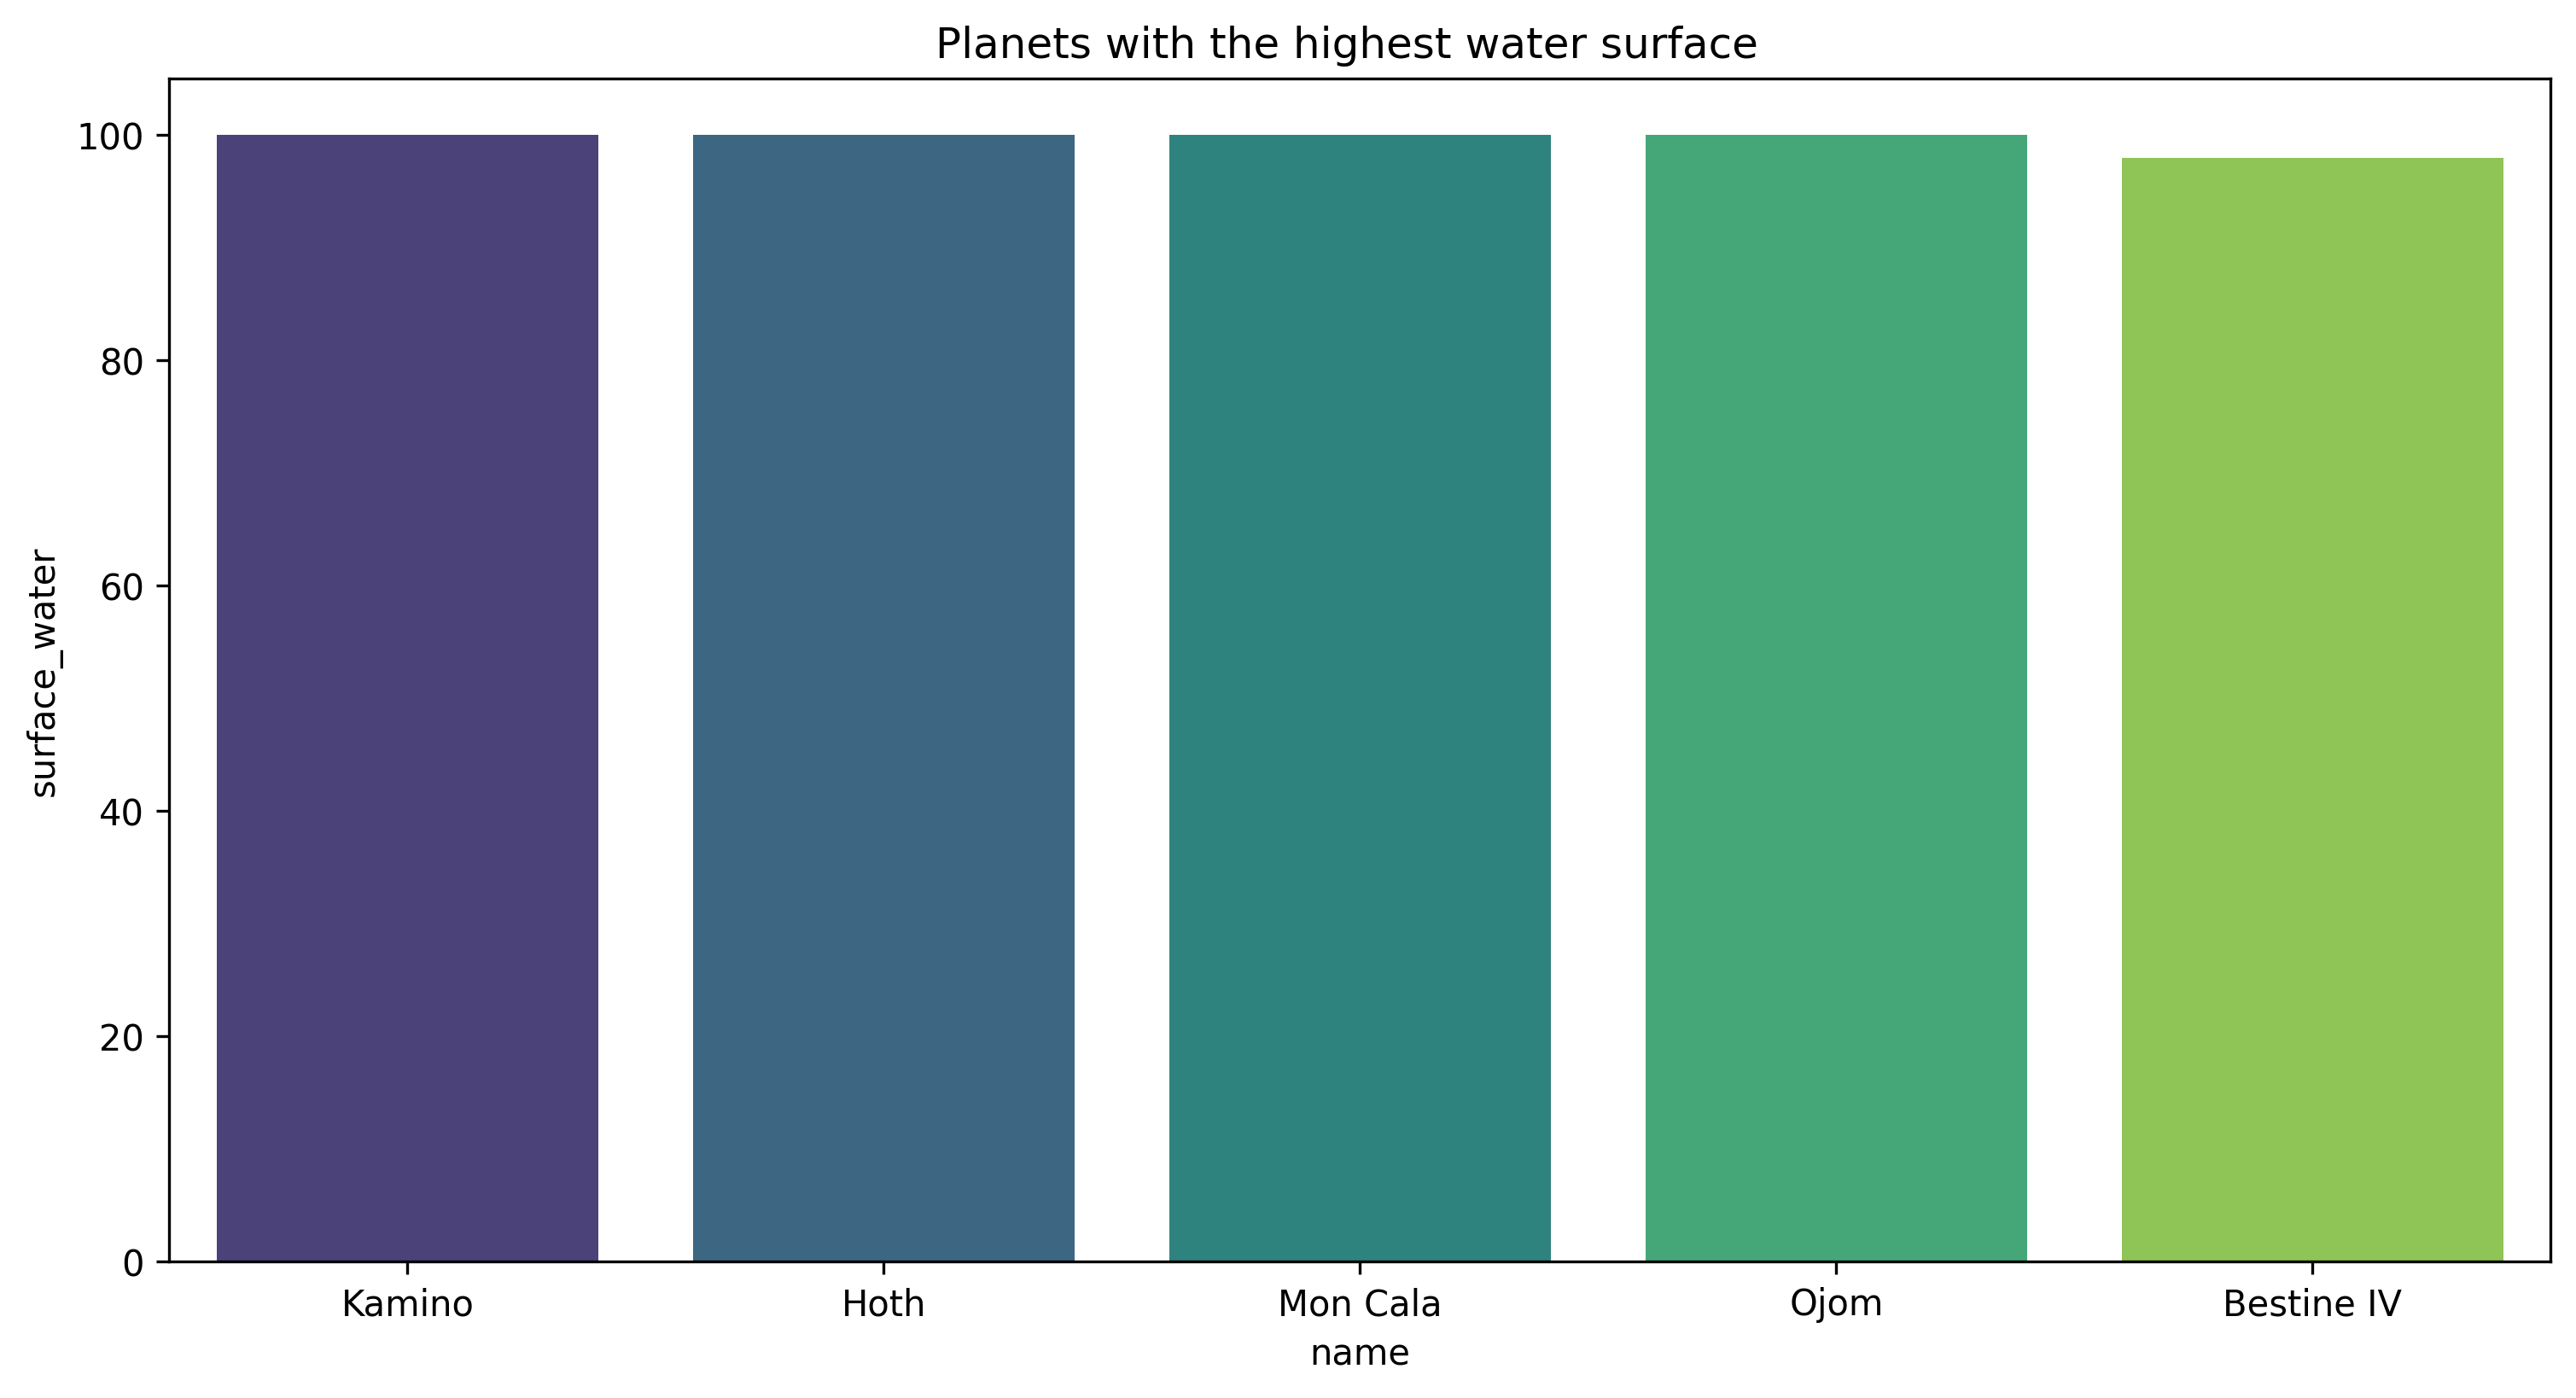

In [63]:
fig, ax = plt.subplots(figsize = (12, 6), dpi = 300)
sns.barplot(data=planets_water.head(5),x="name",y="surface_water",hue="name",palette="viridis")
plt.title("Planets with the highest water surface  ")
plt.savefig("../Output/charts/planets_water.png", dpi=300)

>  As we can see in the output chart, The planets with the highest water surface are *kamino, hoth, mon cala, ojom, bestine IV* with a water surface of *100*